<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.878 · Trabajo Final del Máster · Área 1 · Aula 1</p>
<p style="margin: 0; text-align:right;">20241 - Máster universitario en Ciencias de datos (<i>Data science</i>)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicaciones</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
    <strong>Estudiante:</strong> James Eward Humberstone Morales
</div>

# 1. Análisis exploratorio de los datos

In [1]:
# Carga de librerías
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Carga de los datos

In [2]:
# Carga de los datos
ventas = pd.read_excel('/kaggle/input/tfm-datos/ventas.xlsx')
stock = pd.read_excel('/kaggle/input/tfm-datos/stock.xlsx')
calendario = pd.read_excel('/kaggle/input/tfm-datos/calendario.xlsx')
promociones = pd.read_excel('/kaggle/input/tfm-datos/promociones.xlsx')
precios = pd.read_excel('/kaggle/input/tfm-datos/DatosPrecioMedio.xlsx')
aprovisionamiento = pd.read_excel('/kaggle/input/tfm-datos/DatosCicloAprovisionamiento.xlsx')

## Resumen de los datos

In [3]:
# Función auxiliar para explorar los DataFrames
def explorar_df(df, nombre):
    print(f"\n--- Exploración de {nombre} ---")
    print(f"Número de registros: {df.shape[0]}")
    print("Tipos de variables:")
    print(df.dtypes)
    print("\nValores ausentes por columna:")
    print(df.isnull().sum())
    print("\nValores duplicados:")
    print(df.duplicated().sum())
    # Valores negativos (solo columnas numéricas)
    print("\nValores negativos por columna numérica:")
    columnas_numericas = df.select_dtypes(include='number').columns
    for col in columnas_numericas:
        negativos = (df[col] < 0).sum()
        print(f"{col}: {negativos}")
    print("-" * 50)

In [4]:
# Exploración de cada archivo
explorar_df(ventas, "ventas")
explorar_df(stock, "stock")
explorar_df(calendario, "calendario")
explorar_df(promociones, "promociones")
explorar_df(precios, "precios")
explorar_df(aprovisionamiento, "aprovisionamiento")


--- Exploración de ventas ---
Número de registros: 654408
Tipos de variables:
producto       int64
idSecuencia    int64
udsVenta       int64
dtype: object

Valores ausentes por columna:
producto       0
idSecuencia    0
udsVenta       0
dtype: int64

Valores duplicados:
0

Valores negativos por columna numérica:
producto: 0
idSecuencia: 0
udsVenta: 0
--------------------------------------------------

--- Exploración de stock ---
Número de registros: 654408
Tipos de variables:
producto       int64
idSecuencia    int64
udsStock       int64
dtype: object

Valores ausentes por columna:
producto       0
idSecuencia    0
udsStock       0
dtype: int64

Valores duplicados:
0

Valores negativos por columna numérica:
producto: 0
idSecuencia: 0
udsStock: 0
--------------------------------------------------

--- Exploración de calendario ---
Número de registros: 837
Tipos de variables:
idSecuencia    int64
bolOpen        int64
bolHoliday     int64
dtype: object

Valores ausentes por columna:
idS

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observaciones:</strong>
<ul>
    <li>Se cargaron correctamente los seis conjunto de datos</li>
    <li>No hay valores ausentes en los conjuntos de datos individuales. Es importante ver si existen valores ausentes al unir los conjuntos de datos, esto se hará posteriormente.</li>
    <li>No hay valores negativos en las columnas numéricas.</li>
    <li>No hay registros duplicados en los conjuntos de datos. Hay que revisar si existen duplicados en los conjuntos de <strong>ventas y stock</strong>  al agruparlos por la clave producto - idSecuecnia</li>
</ul>
</div>

In [5]:
# Función para convertir de secuencias a fechas
def convertir_a_fecha(df, columnas_fecha):
    for col in columnas_fecha:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col].astype(str), format='%Y%m%d')
    return df

# Función para explorar el rango de fechas
def rango_fechas(df, col_fecha):
    if col_fecha in df.columns:
        print(f"Rango de fechas en {col_fecha}: {df[col_fecha].min().date()} → {df[col_fecha].max().date()}")


# Convertir fechas en cada DataFrame
ventas = convertir_a_fecha(ventas, ['idSecuencia'])
stock = convertir_a_fecha(stock, ['idSecuencia'])
calendario = convertir_a_fecha(calendario, ['idSecuencia'])
promociones = convertir_a_fecha(promociones, ['idSecuenciaIni', 'idSecuenciaFin'])

In [6]:
# Función para obtener el resumen estádistico
def estadisticas_df(df, nombre="DataFrame"):
    print(f"\n=== Estadísticas para {nombre} ===")
    
    # Resumen estadístico de columnas numéricas
    columnas_numericas = df.select_dtypes(include='number').columns
    if len(columnas_numericas) > 0:
        print("\n Resumen estadístico (columnas numéricas):")
        print(df[columnas_numericas].describe())
    else:
        print("\n No se encontraron columnas numéricas.")

    # Rango de fechas para columnas tipo datetime o date
    columnas_fecha = df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]', 'object']).columns
    columnas_fecha = [col for col in columnas_fecha if pd.to_datetime(df[col], errors='coerce').notnull().all()]
    
    print("\n Rango de fechas por columna de fecha:")
    fechas_encontradas = False
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]) or df[col].apply(lambda x: isinstance(x, (pd.Timestamp, pd._libs.tslibs.timestamps.Timestamp, datetime.date))).all():
            fechas_encontradas = True
            print(f"{col}: {df[col].min()} → {df[col].max()}")
    if not fechas_encontradas:
        print(" No se encontraron columnas de fecha.")
    
    print("=" * 50)


estadisticas_df(ventas, "ventas")
estadisticas_df(stock, "stock")
estadisticas_df(calendario, "calendario")
estadisticas_df(promociones, "promociones")
estadisticas_df(precios, "precios")
estadisticas_df(aprovisionamiento, "aprovisionamiento")


=== Estadísticas para ventas ===

 Resumen estadístico (columnas numéricas):
            producto       udsVenta
count  654408.000000  654408.000000
mean      502.115213       1.438500
std       291.228968       2.698971
min         1.000000       0.000000
25%       247.000000       0.000000
50%       506.500000       0.000000
75%       754.000000       2.000000
max      1000.000000     181.000000

 Rango de fechas por columna de fecha:
idSecuencia: 2022-11-05 00:00:00 → 2024-11-05 00:00:00

=== Estadísticas para stock ===

 Resumen estadístico (columnas numéricas):
            producto       udsStock
count  654408.000000  654408.000000
mean      502.115213      56.037996
std       291.228968      43.176785
min         1.000000       0.000000
25%       247.000000      33.000000
50%       506.500000      49.000000
75%       754.000000      71.000000
max      1000.000000     947.000000

 Rango de fechas por columna de fecha:
idSecuencia: 2022-11-06 00:00:00 → 2024-11-06 00:00:00

=== Es

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observación:</strong>
<ul>
    <li>Existe rangos de fechas entre los datos de ventas, stock y calendario. Esto es un problema porque hay productos que tienen ventas el 2022-11-05 y no se tienen los datos del stock y del calendario, por lo que al unir la bases habrán datos ausentes que hay que tratar, más adelante se explicará la estrategia  a seguir para cada caso.</li> 
</ul>
</div>

## Imputación de fecha faltantante en el calendario 

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p> Como se comento anteriormente, al unir la base de datos de ventas con la de calendario, habrán valores nulos porque en la ventas hay registros para a fecha 2022-11-05 y en el calendario no hay una entrada para dicha fecha. Por lo que primero se determinará el número de registros afectados al unir las bases</p>
</div>

In [7]:
# Fecha objetivo
fecha_objetivo = pd.to_datetime('2022-11-05')

# Filtrar registros con esa fecha
ventas_fecha_objetivo = ventas[ventas['idSecuencia'] == fecha_objetivo]

# Contar registros
num_registros = ventas_fecha_objetivo.shape[0]
total_registros = ventas.shape[0]
porcentaje = (num_registros / total_registros) * 100

# Mostrar resultados
print(f" Registros con fecha {fecha_objetivo.date()}: {num_registros}")
print(f" Porcentaje respecto al total: {porcentaje:.4f}%")

 Registros con fecha 2022-11-05: 894
 Porcentaje respecto al total: 0.1366%


<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>Existen 894 registros (0.1366%) que tendrían valores ausentes al unir las bases de datos. <strong>La solución más fácil sería no incluirlos en el análisis. Sin embargo, se corre el riesgo de perder información relevante sobre todo si las unidades vendidas son mayor a cero.</strong></li> 
</ul>
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Estrategia para tratar los valores ausentes al unir las bases:</strong>
<pSe propone la siguiente estrategia:</p>
        <ol>
            <li>Obtener el día de la semana de la fecha 2022-11-5</li>
            <li>Obtener los datos de los datos de para las fechas 2023-11-5 y 2024-11-5 para tomarlos como referencia</li>
            <li>Calcular el día de la semana de todas las fechas y determinar el porcentaje de veces que el punto de venta se encuentra abierto en cada día</li>
            <li>Comparar todo los resultados para concluir si la fecha 2022-11-5 el punto de venta estaba abierto o no</li>
            <li>Agregar el registro al conjunto de datos <strong>calendario</strong>.</li>
        </ol>
</div>

In [8]:
# Fechas comparables
fechas_comparar = ['2023-11-05', '2024-11-05']
calendario[calendario['idSecuencia'].isin(pd.to_datetime(fechas_comparar))]

for fecha in fechas_comparar:
    fila = calendario[calendario['idSecuencia'] == pd.to_datetime(fecha)]
    if not fila.empty:
        dia_semana = fila['idSecuencia'].dt.day_name().values[0]
        print(f"{fecha} ({dia_semana}): bolOpen = {fila['bolOpen'].values[0]}, bolHoliday = {fila['bolHoliday'].values[0]}")

print("2022-11-05 fue un", pd.to_datetime('2022-11-05').day_name())

2023-11-05 (Sunday): bolOpen = 0, bolHoliday = 1
2024-11-05 (Tuesday): bolOpen = 1, bolHoliday = 0
2022-11-05 fue un Saturday


In [9]:
# Agregar columna con el nombre del día de la semana
calendario['dia_semana'] = calendario['idSecuencia'].dt.day_name()

# Calcular la proporción de días abiertos por día de la semana
resumen_dias = calendario.groupby('dia_semana')['bolOpen'].agg(['count', 'sum', 'mean']).rename(columns={
    'count': 'total_dias',
    'sum': 'dias_abiertos',
    'mean': 'proporcion_abiertos'
}).sort_values('proporcion_abiertos', ascending=False)

# Mostrar resultados
print("\nResumen de apertura por día de la semana:")
print(resumen_dias)


Resumen de apertura por día de la semana:
            total_dias  dias_abiertos  proporcion_abiertos
dia_semana                                                
Thursday           119            118             0.991597
Tuesday            120            118             0.983333
Saturday           119            117             0.983193
Wednesday          120            117             0.975000
Friday             119            113             0.949580
Monday             120            110             0.916667
Sunday             120             19             0.158333


<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>El <strong>2022-11-05</strong> fue sábado y como se puede observar en la tabla anterior el 98.32% de los sábados el punto de venta se encuentra abierto. <strong>Por tanto, se concluye que el punto de venta estabá abierto el 2022-11-05</strong>.</li> 
</ul>
</div>

In [10]:
# Filtrar solo los sábados de noviembre
sabados_noviembre = calendario[
    (calendario['idSecuencia'].dt.month == 11) &
    (calendario['idSecuencia'].dt.dayofweek == 5)  # 5 = Sábado
]

# Calcular el porcentaje de sábados de noviembre que son festivos
total_sabados = sabados_noviembre.shape[0]
sabados_festivos = sabados_noviembre['bolHoliday'].sum()
porcentaje_festivos = (sabados_festivos / total_sabados) * 100 if total_sabados > 0 else 0

# Mostrar resultados
print(f" Total de sábados en noviembre: {total_sabados}")
print(f" Sábados que son festivos: {sabados_festivos}")
print(f" Porcentaje de sábados festivos en noviembre: {porcentaje_festivos:.2f}%")

 Total de sábados en noviembre: 12
 Sábados que son festivos: 0
 Porcentaje de sábados festivos en noviembre: 0.00%


<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>El porcentaje de sábados festivos en el mes de noviembre es 0.0% por tanto, se concluye que el <strong>2022-11-05 no es un día festivo.</strong> Por tanto, se creará el registro en la base de calendario antes de unirla con la base de ventas. </li>
</ul>
</div>

In [11]:
# Crear la nueva fila como DataFrame
nueva_fila = pd.DataFrame({
    'idSecuencia': [pd.to_datetime('2022-11-05')],
    'bolOpen': [1],
    'bolHoliday': [0],
    'dia_semana': ['Saturday']
})

# Agregarla al DataFrame original
calendario = pd.concat([calendario, nueva_fila], ignore_index=True)

# Asegurarse de que esté ordenado por fecha
calendario = calendario.sort_values('idSecuencia').reset_index(drop=True)

# Verificar que se haya insertado correctamente
print(calendario[calendario['idSecuencia'] == pd.to_datetime('2022-11-05')])

  idSecuencia  bolOpen  bolHoliday dia_semana
0  2022-11-05        1           0   Saturday


##  Unión de las bases ventas y stock

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p> Como se comento anteriormente, al unir la base de datos de ventas con la de stock, habrán valores nulos porque en la ventas hay registros para a fecha 2022-11-05 y en el stock no hay una entrada para dicha fecha. Por lo que se propone la siguiente estrategia</p>

<strong>Estrategia:</strong>
<p>Para imputar los valores faltantes en udsStock luego de la unión de las bases se seguirá la siguiente estrategia:</p>
<ul>
    <li>Unir las bases de datos <strong>ventas</strong> y <strong>stock</strong> por medio de las claves </strong>(producto, idsecuencia)</strong>.</li>
    <li>Añadir la columna <strong>udsStock</strong> al conjunto de datos de <strong>ventas</strong>.</li>
    <li>Para los registros de ventas que no tienen stock informado (NaN), imputar con: $udsStock_t = udsStock_t+1 + udsVenta_t$ ,de esta manera se asume que el sotck no tuvo reemplazo luego de la venta</li>
    
</ul>
</div>
</div>

In [12]:
# Unir stock a ventas por producto y fecha
ventas_stock = pd.merge(
    ventas,
    stock,
    on=['producto', 'idSecuencia'],
    how='left'  # conservar todas las ventas
)

In [13]:
# Ordenar por producto y fecha para garantizar la secuencia temporal
ventas_stock = ventas_stock.sort_values(['producto', 'idSecuencia'])

# Crear la columna con udsStock del día siguiente por producto
ventas_stock['udsStock_siguiente'] = ventas_stock.groupby('producto')['udsStock'].shift(-1)

# Imputar udsStock solo si está nulo
ventas_stock['udsStock'] = ventas_stock.apply(
    lambda row: row['udsVenta'] + row['udsStock_siguiente']
    if pd.isna(row['udsStock']) else row['udsStock'],
    axis=1
)

# Eliminar la columna auxiliar
ventas_stock.drop(columns=['udsStock_siguiente'], inplace=True)

In [14]:
print("Valores nulos en udsStock", ventas_stock['udsStock'].isnull().sum())

Valores nulos en udsStock 0


## Integración de la base de datos calendario

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p>Para integrar la base de datos de calendario se seguirá la siguiente estrategia:</p>
    
<strong>Estrategia:</strong>
<ul>
    <li>Crear en la base de datos calendario las variables numéricas: <strong>year, month, day, day_of_week, week_of_year y week_of_month</strong></li>
    <li>Unir las bases por medio de la clave <strong>idSecuencia</strong></li>
    
</ul>
</div>

In [15]:
# Crear variables de tiempo numéricas
calendario['year'] = calendario['idSecuencia'].dt.year
calendario['month'] = calendario['idSecuencia'].dt.month
calendario['day'] = calendario['idSecuencia'].dt.day
calendario['day_of_week'] = calendario['idSecuencia'].dt.weekday  # lunes = 0
calendario['week_of_year'] = calendario['idSecuencia'].dt.isocalendar().week

# Función para calcular la semana del mes
def week_of_month(dt):
    first_day = dt.replace(day=1)
    dom = dt.day
    adjusted_dom = dom + first_day.weekday()  # ajusta según inicio de semana
    return int((adjusted_dom - 1) / 7 + 1)

calendario['week_of_month'] = calendario['idSecuencia'].apply(week_of_month)


In [16]:
# Unir calendario a ventas_stock
ventas_stock_calendario = pd.merge(
    ventas_stock,
    calendario,
    on='idSecuencia',
    how='left'  # conserva todas las fechas presentes en ventas
)

In [17]:
print("Registros totales:", ventas_stock_calendario.shape[0])
print("Valores nulos en bolOpen:", ventas_stock_calendario['bolOpen'].isnull().sum())
print("Valores nulos en bolHoliday:", ventas_stock_calendario['bolHoliday'].isnull().sum())

Registros totales: 654408
Valores nulos en bolOpen: 0
Valores nulos en bolHoliday: 0


##  Integracion de la base de datos promociones

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p>Finalmente, para unir la base de datos <strong>promociones</strong> se seguirá la siguiente estrategia:</p>

<strong>Estrategia:</strong>
<ul>
    <li><strong>Expandir las promociones a nivel diario:</strong> generar filas por (producto, fecha) para cada día que dura la promoción.</li>
    <li>Crear una tabla auxiliar con todas las fechas en las que hubo promoción.</li>
    <li>Hacer una unión con el dataset <strong>ventas_stock_calendario</strong> para marcar con <strong>bolPromotion = 1</strong> los días con promoción.</li>
</ul>
</div>

In [18]:
# Lista para almacenar promociones expandidas
promo_expandidas = []

# Expandir cada promoción día a día
for _, row in promociones.iterrows():
    fechas = pd.date_range(start=row['idSecuenciaIni'], end=row['idSecuenciaFin'])
    for fecha in fechas:
        promo_expandidas.append({'producto': row['producto'], 'idSecuencia': fecha})

# Crear DataFrame con todas las fechas de promoción
promo_df = pd.DataFrame(promo_expandidas)
promo_df = pd.DataFrame(promo_expandidas).drop_duplicates(subset=['producto', 'idSecuencia'])
promo_df['bolPromotion'] = 1


In [19]:
# Hacer left join para marcar días con promoción
final_df = pd.merge(
    ventas_stock_calendario,
    promo_df,
    on=['producto', 'idSecuencia'],
    how='left'
)

# Rellenar con 0 los días sin promoción
final_df['bolPromotion'] = final_df['bolPromotion'].fillna(0).astype(int)


In [22]:
print("Total de registros:", final_df.shape[0])
print("Valores nulos en bolPromotion:", final_df['bolPromotion'].isnull().sum())

Total de registros: 654408
Valores nulos en bolPromotion: 0


### Guardado del nuevo set de datos

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p>Se guardará este nuevo conjunto de datos para luego realizar un análisis sobre la rotura del stock, para evitar que los modelos aprendan patrones de demanda falsa debida a roturas de stock.</p>
</div>

In [23]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654408 entries, 0 to 654407
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   producto       654408 non-null  int64         
 1   idSecuencia    654408 non-null  datetime64[ns]
 2   udsVenta       654408 non-null  int64         
 3   udsStock       654408 non-null  float64       
 4   bolOpen        654408 non-null  int64         
 5   bolHoliday     654408 non-null  int64         
 6   dia_semana     654408 non-null  object        
 7   year           654408 non-null  int32         
 8   month          654408 non-null  int32         
 9   day            654408 non-null  int32         
 10  day_of_week    654408 non-null  int32         
 11  week_of_year   654408 non-null  UInt32        
 12  week_of_month  654408 non-null  int64         
 13  bolPromotion   654408 non-null  int64         
dtypes: UInt32(1), datetime64[ns](1), float64(1), int32(4

In [24]:
# Exportar a Excel
final_df.to_excel('datos_completos.xlsx', index=False)

## Imputación de la rotura del stock

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p>Para evitar que el modelo aprenda falsamente que la demanda fue cero, cuando en realidad podría haber existido una rotura de stock se seguira la siguiente estrategia.</p>
 <strong>Estrategia:</strong>
 <ul>
     <li>Utilizar la siguiente condicion <strong>Si udsVenta = 0 y udsStock = 0 y bolOpen = 1 </strong> para identificar registros con rotura de stock</li>
     <li>Sustistuir el valor de udsVenta con la <strong>mediana</strong> del producto, ya que es una medida robusta a valores extremos y funciona bien con pocos datos.</li>
     <li>Finalmente, se guardara la base de datos resultante para su posterior análisis y visualización.</li>
 </ul>
</div>

In [2]:
# carga de la base de datos
final_df = pd.read_excel('/kaggle/working/datos_completos.xlsx')

In [25]:
final_df.head()

,producto,idSecuencia,udsVenta,udsStock,bolOpen,bolHoliday,dia_semana,year,month,day,day_of_week,week_of_year,week_of_month,bolPromotion
0,1,2022-11-05,40,188.0,1,0,Saturday,2022,11,5,5,44,1,1
1,1,2022-11-06,0,148.0,0,1,Sunday,2022,11,6,6,44,1,1
2,1,2022-11-07,12,148.0,1,0,Monday,2022,11,7,0,45,2,1
3,1,2022-11-08,28,136.0,1,0,Tuesday,2022,11,8,1,45,2,1
4,1,2022-11-09,14,306.0,1,0,Wednesday,2022,11,9,2,45,2,1


In [26]:
# Función para reconstrucción de ventas en caso de rotura de stock
def reconstruir_roturas_stock(df, col_producto='producto', col_fecha='idSecuencia',
                               col_venta='udsVenta', col_stock='udsStock',
                               col_open='bolOpen'):
    df = df.copy()

    # Identificar roturas de stock
    df['rotura_stock'] = ((df[col_venta] == 0) &
                          (df[col_stock] == 0) &
                          (df[col_open] == 1)).astype(int)

    # Calcular mediana por producto (solo donde hubo ventas)
    medianas = df[df[col_venta] > 0].groupby(col_producto)[col_venta].median()

    # Reconstrucción con valores enteros
    def reconstruir(row):
        if row['rotura_stock'] == 1:
            return int(round(medianas.get(row[col_producto], 0)))
        return row[col_venta]

    df['udsVenta_reconstruida'] = df.apply(reconstruir, axis=1)

    return df

In [27]:
# Reconstruir las ventas 
df_reconstruido = reconstruir_roturas_stock(final_df)

In [28]:
# Mostrar ejemplos
ejemplos = df_reconstruido[df_reconstruido['rotura_stock'] == 1][
    ['producto', 'idSecuencia', 'udsVenta', 'udsStock', 'bolOpen', 'udsVenta_reconstruida']
]

ejemplos.head()

,producto,idSecuencia,udsVenta,udsStock,bolOpen,udsVenta_reconstruida
191,1,2023-05-15,0,0.0,1,9
404,1,2023-12-14,0,0.0,1,9
1136,2,2023-12-14,0,0.0,1,9
1868,3,2023-12-14,0,0.0,1,7
2600,4,2023-12-14,0,0.0,1,5


##  Identificación de valores atípicos en udsVenta

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
 <strong>Estrategia:</strong>
 <ul>
     <li>Identificar los valores atípicos por producto, por medio del método del rango intercuartílico (IQR).</li>
     <li>Graficar el top 5 de productos más vendidos para visuallizar su distribución</li>
     <li>Graficar el top 5 de productos más irregulares (con más valores atípicos) para visualizar su ddistribución.</li>
     <li>Con base a las observaciones decidir la estrategia de imputación de los valores atípicos.</li>
 </ul>
</div>

In [29]:
# Función para marcar outliers usando el método IQR por producto
def detectar_outliers_por_producto(df, col_producto='producto', col_venta='udsVenta_reconstruida'):
    outlier_list = []

    for producto_id, grupo in df.groupby(col_producto):
        q1 = grupo[col_venta].quantile(0.25)
        q3 = grupo[col_venta].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        grupo = grupo.copy()
        grupo['is_outlier'] = ~grupo[col_venta].between(limite_inferior, limite_superior)
        outlier_list.append(grupo)

    return pd.concat(outlier_list).reset_index(drop=True)


In [30]:
# Aplicamos la función al DataFrame reconstruido
df_reconstruido = detectar_outliers_por_producto(df_reconstruido)

In [31]:
# Verificamos cuántos valores atípicos se encontraron
print("Cantidad total de valores atípicos detectados:", df_reconstruido['is_outlier'].sum())

Cantidad total de valores atípicos detectados: 40413


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <p>Graficar el top 5 de productos más vendidos para visuallizar su distribución</p> 
</div>

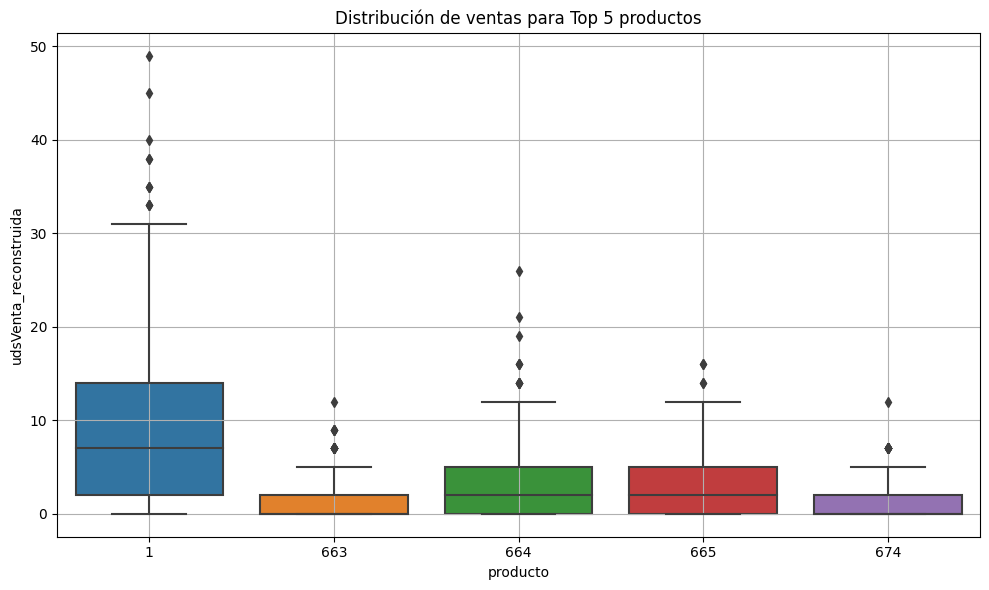

In [32]:
# Seleccionar Top 5 productos con más ventas
top_productos = df_reconstruido['producto'].value_counts().head(5).index.tolist()

# Filtrar
df_top = df_reconstruido[df_reconstruido['producto'].isin(top_productos)]

# Crear boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top, x='producto', y='udsVenta_reconstruida')
plt.title('Distribución de ventas para Top 5 productos')
plt.grid(True)
plt.tight_layout()
plt.savefig("boxplot_Top5.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observaciones:</strong>
<ul>
    <li>Los productos con id 1, 664 y 665 tienen una mediana de ventas baja entre 1 y 3 unidades. Sin embargo, presentan outliers altos: tienen ventas de más de 20 unidades en un día. Esto sugiere que son productos estables la mayoría del tiempo, pero con eventos inusuales, posiblemente promociones.</li>
    <li>Los productos con id 663 y 674 son productos de venta irregular ya que su mediana es 0. Esto sugiere que estos productos casi nunca se venden, pero de repente tienen días con picos enormes.</li>
</ul>
</div>


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
 <p>A continuación se graficará el top 5 de productos con más valores atípicos para visualizar su ddistribución.</p>
</div>

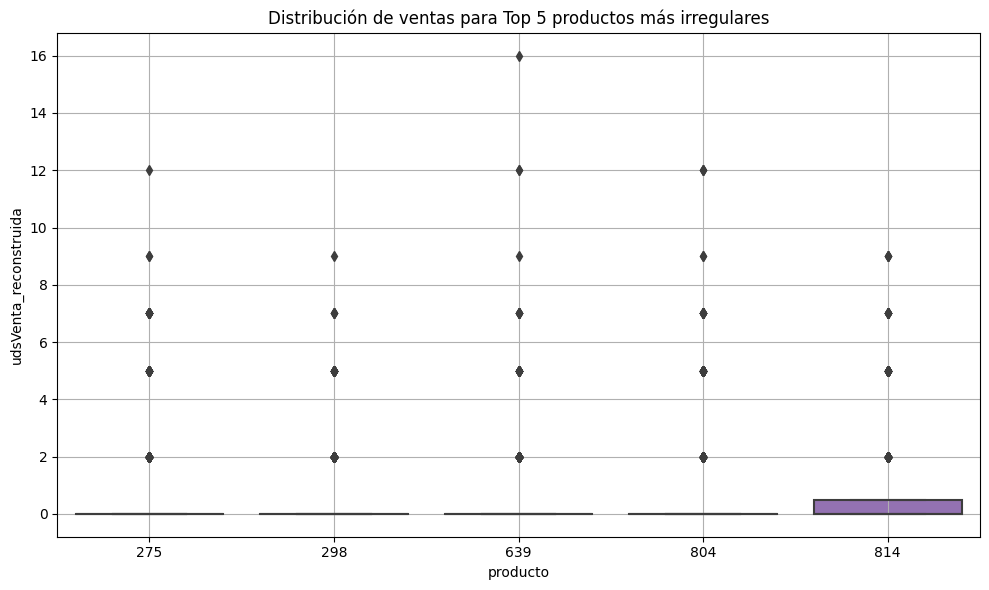

In [33]:
# Obtener Top 5 productos con más outliers
top_outlier_productos = df_reconstruido[df_reconstruido['is_outlier']].groupby('producto').size().sort_values(ascending=False).head(5).index.tolist()

# Filtrar datos solo de esos productos
df_top_outliers = df_reconstruido[df_reconstruido['producto'].isin(top_outlier_productos)]

# Crear boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_outliers, x='producto', y='udsVenta_reconstruida')
plt.title('Distribución de ventas para Top 5 productos más irregulares')
plt.grid(True)
plt.tight_layout()
plt.savefig("boxplot_Top5_irregulares.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observaciones:</strong>
<ul>
    <li><strong>Valores extremos muy marcados</strong>. En todos los productos del top la mayoría de los datos están concentrados en entre 0 y 1. Pero algunos días se vendieron cantidades mucho más altas, especialmente el producto 639, que tiene ventas de hasta 16 unidades en un día.
</li>
    <li><strong>La mediana está pegada a 0 en casi todos</strong>. Esto sugiere que estos productos casi nunca se venden, pero de repente tienen días con picos enormes.</li>
</ul>
</div>

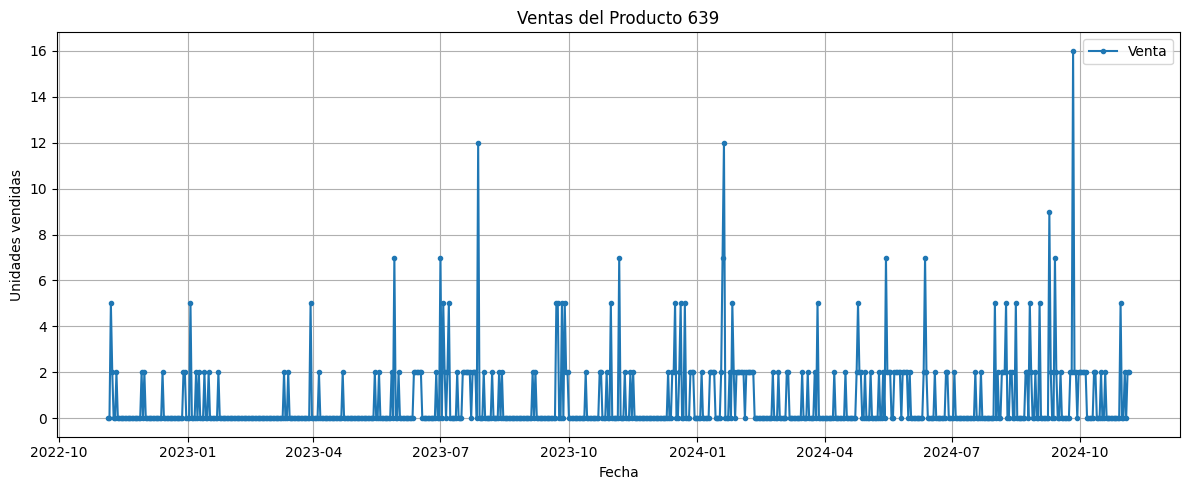

In [34]:
producto_id = 639  

df_prod = df_reconstruido[df_reconstruido['producto'] == producto_id]

plt.figure(figsize=(12, 5))
plt.plot(df_prod['idSecuencia'], df_prod['udsVenta_reconstruida'], label='Venta', marker='o', markersize=3)
plt.title(f'Ventas del Producto {producto_id}')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observación:</strong>
<ul>
    <li>El gráfico muestra las ventas del producto con id 639, se puede evidenciar que la mayoría de ventas estan en 0. Esto sugiere que este producto casi nunca se venden, pero de repente tienen días con picos altos.</li>
</ul>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Estrategia para imputar valores atípicos:</strong>
<ul>
    <li>Se utilizará la <srong>mediana</strong> como medidad de imputación por ser robusta a los valores extremos.</li>
    <li>En los productos donde la mediana es 0 no se imputarán los valores atípicos, ya que imputarlos con cero implicaría eliminar por completo los pocos eventos de venta, lo que sería una pérdida de información potencialmente significativa.</li>
</ul>
</div>

In [35]:
# Calcular la mediana de ventas por producto
medianas = df_reconstruido.groupby('producto')['udsVenta_reconstruida'].median()

# Filtrar productos con mediana > 0
productos_mediana_gt0 = medianas[medianas > 0].index

# Crear diccionario con medianas redondeadas
medianas_dict = medianas.round().astype(int).to_dict()

# Función de imputación con mediana redondeada
def imputar_mediana_redondeada(row):
    if row['is_outlier'] and row['producto'] in productos_mediana_gt0:
        return medianas_dict[row['producto']]
    return row['udsVenta_reconstruida']

# Aplicar imputación
df_reconstruido['udsVenta_imputada'] = df_reconstruido.apply(imputar_mediana_redondeada, axis=1)

## Visualización de la imputación   

In [36]:
df_top = df_reconstruido[df_reconstruido['producto'].isin(top_productos)]

df_top5_long = df_top.melt(
    id_vars=['producto', 'idSecuencia'],
    value_vars=['udsVenta_reconstruida', 'udsVenta_imputada'],
    var_name='tipo',
    value_name='venta'
)

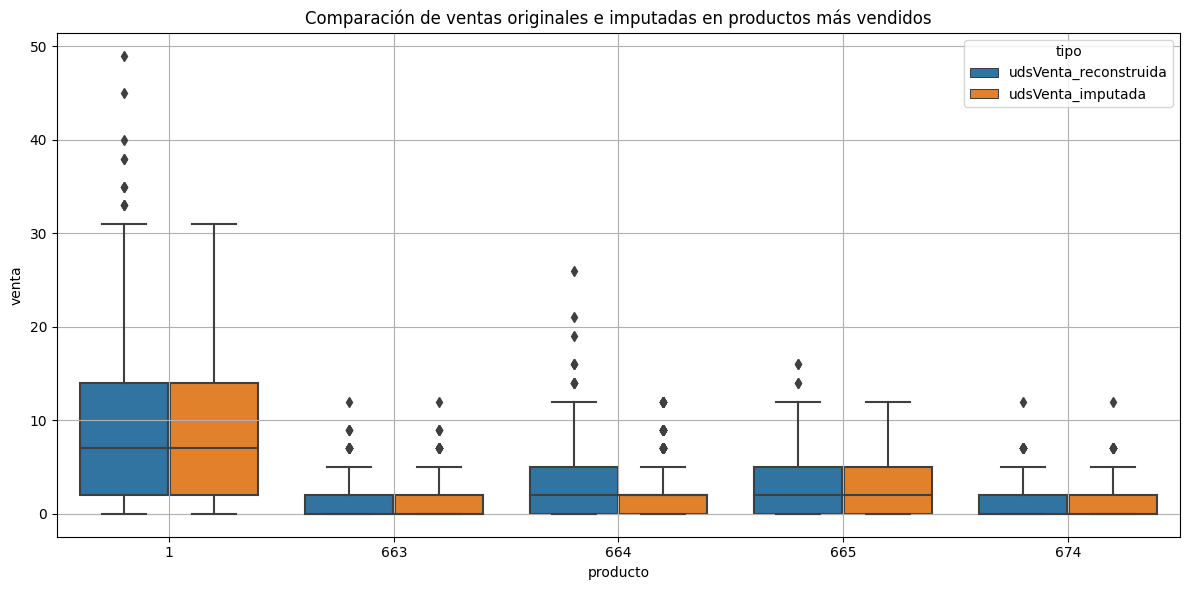

In [37]:
# Crear boxplots comparativos
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5_long, x='producto', y='venta', hue='tipo')
plt.title('Comparación de ventas originales e imputadas en productos más vendidos')
plt.grid(True)
plt.tight_layout()
plt.savefig("boxplot_comparcion1.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observación:</strong>
<ul>
    <li>Se puede observar que los productos con id 1, 664 y 665 sus valores atípicos fueron imputados, en cambio los productos con id 663 y 674 mantienen sus valores atípicos porque su mediana es 0.</li>
</ul>
</div>

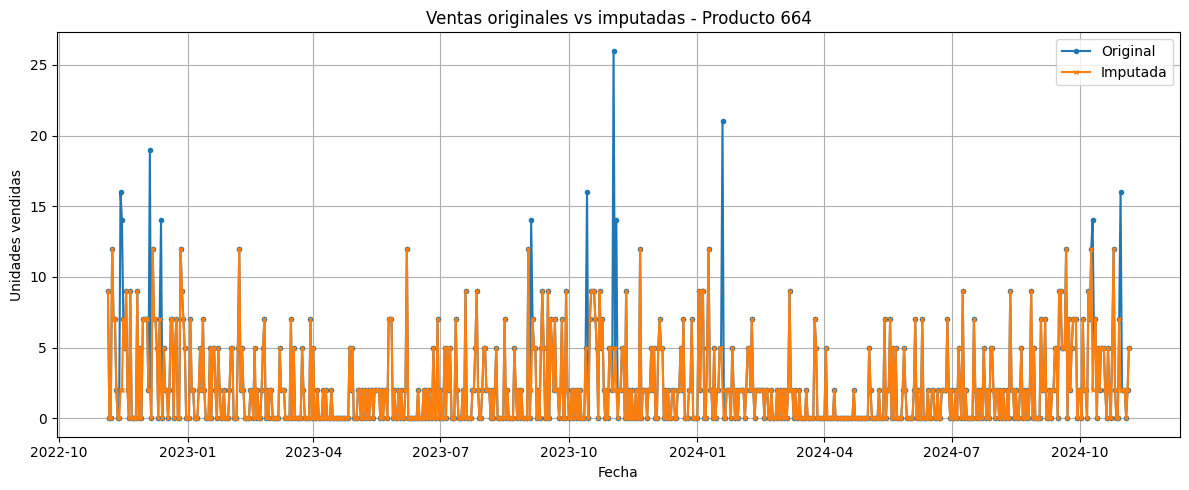

In [40]:
producto_id = 664  

df_prod = df_reconstruido[df_reconstruido['producto'] == producto_id]

plt.figure(figsize=(12, 5))
plt.plot(df_prod['idSecuencia'], df_prod['udsVenta_reconstruida'], label='Original', marker='o', markersize=3)
plt.plot(df_prod['idSecuencia'], df_prod['udsVenta_imputada'], label='Imputada', marker='x', markersize=3)
plt.title(f'Ventas originales vs imputadas - Producto {producto_id}')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
df_top_outliers = df_reconstruido[df_reconstruido['producto'].isin(top_outlier_productos)]

df_top5_long = df_top_outliers.melt(
    id_vars=['producto', 'idSecuencia'],
    value_vars=['udsVenta_reconstruida', 'udsVenta_imputada'],
    var_name='tipo',
    value_name='venta'
)

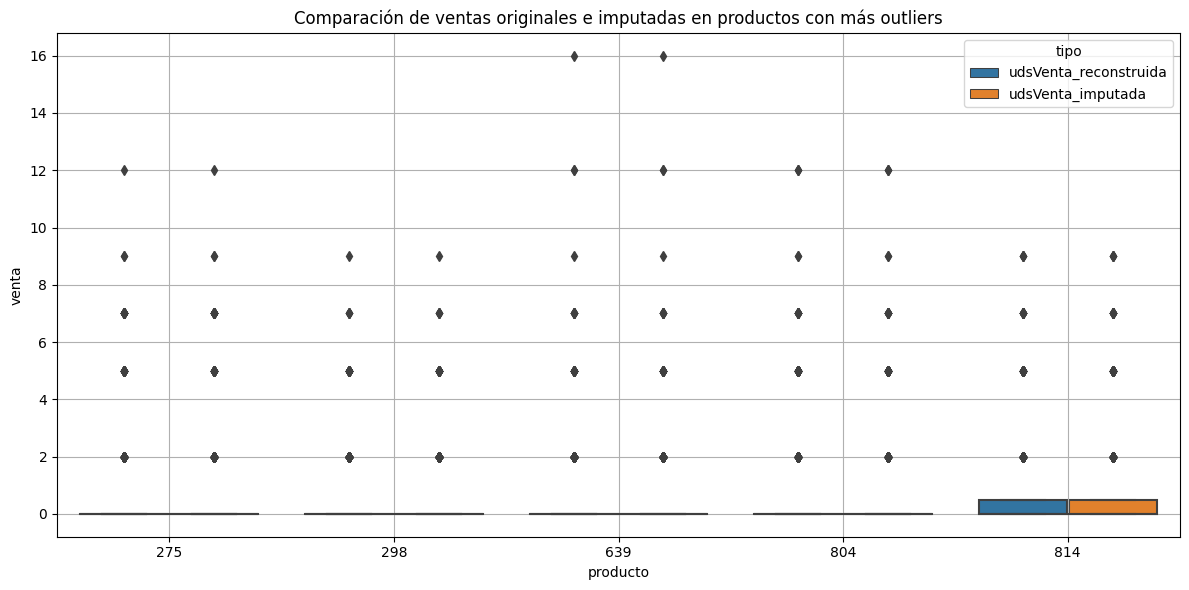

In [42]:
# Crear boxplots comparativos
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5_long, x='producto', y='venta', hue='tipo')
plt.title('Comparación de ventas originales e imputadas en productos con más outliers')
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observación:</strong>
<ul>
    <li>Se comprueba que los productos con mediana 0 no son imputados, para no eliminar por completo los pocos eventos de venta.</li>
</ul>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>Se optó por una estrategia de imputación condicional, con el objetivo de preservar la estructura temporal de las series de ventas.</li>
    <li>La imputación consistió en reemplazar los valores atípicos por la mediana de ventas del mismo producto, siempre que esta fuera mayor que cero.</li>
    <li>La mediana proporciona un valor representativo, robusto ante extremos, y mantiene la coherencia del comportamiento típico del producto.</li>
    <li>En los productos donde la mediana es 0 no se imputaron los valores atípicos, ya que imputarlos con cero implica eliminar por completo los pocos eventos de venta, lo que se traduce en una pérdida de información relevante.</li>
</ul>
</div>

# 2. Ingeniría de características

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
 <p>Con el fin de enriquecer el conjunto de datos y facilitar posteriores análisis como la clusterización mediante K-Medias, se crearán variables que resumen el comportamiento estadístico de cada producto. Estas variables permiten caracterizar las series de ventas más allá del valor puntual diario, y capturan propiedades estructurales de la demanda.</p>
</div>

In [43]:
# Crear tabla resumen
tabla_resumen = pd.DataFrame({
    'Variable': ['median_venta', 'cv', 'outlier_rate'],
    'Tipo de dato': ['Numérica', 'Numérica', 'Numérica'],
    'Descripción': [
        'Mediana de unidades vendidas por producto en el periodo analizado.',
        'Coeficiente de variación: medida de la dispersión relativa de las ventas.',
        'Proporción de días/períodos en los que las ventas fueron detectadas como atípicas.'
    ],
    'Propósito': [
        'Capturar el nivel típico de ventas evitando distorsión por valores extremos.',
        'Medir la estabilidad o irregularidad del comportamiento de ventas.',
        'Detectar productos con comportamiento extremo frecuente.'
    ]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Mostrar la tabla
display(tabla_resumen)

,Variable,Tipo de dato,Descripción,Propósito
0,median_venta,Numérica,Mediana de unidades vendidas por producto en el periodo analizado.,Capturar el nivel típico de ventas evitando distorsión por valores extremos.
1,cv,Numérica,Coeficiente de variación: medida de la dispersión relativa de las ventas.,Medir la estabilidad o irregularidad del comportamiento de ventas.
2,outlier_rate,Numérica,Proporción de días/períodos en los que las ventas fueron detectadas como atípicas.,Detectar productos con comportamiento extremo frecuente.


In [44]:
# Calcular estadísticas por producto
stats = df_reconstruido.groupby('producto').agg(
    mean_venta=('udsVenta_imputada', 'mean'),
    std_venta=('udsVenta_imputada', 'std'),
    median_venta=('udsVenta_imputada', 'median'),
    outlier_rate=('is_outlier', 'mean')
)

# Calcular el coeficiente de variación
stats['cv'] = stats['std_venta'] / stats['mean_venta']

# Agregar el coeficiente de variación al conjunto de datos
df_reconstruido = df_reconstruido.merge(
    stats[['median_venta','cv', 'outlier_rate']],
    on='producto',
    how='left'
)

In [45]:
df_reconstruido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654408 entries, 0 to 654407
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   producto               654408 non-null  int64         
 1   idSecuencia            654408 non-null  datetime64[ns]
 2   udsVenta               654408 non-null  int64         
 3   udsStock               654408 non-null  float64       
 4   bolOpen                654408 non-null  int64         
 5   bolHoliday             654408 non-null  int64         
 6   dia_semana             654408 non-null  object        
 7   year                   654408 non-null  int32         
 8   month                  654408 non-null  int32         
 9   day                    654408 non-null  int32         
 10  day_of_week            654408 non-null  int32         
 11  week_of_year           654408 non-null  UInt32        
 12  week_of_month          654408 non-null  int6

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<p>Se guardará la base de datos para su posterior análisis, previamente se removerán las siguientes columnas:</p>
<ul>
    <li><strong>udsVenta:</strong> Será remplazada por la varible <strong>udsVenta_imputada</strong>. </li>
    <li><strong>udsStock</strong>: No sirve como feature para utilizarla en el modelo (ya que no la conocemos a futuro), su uso es explicar las ventas a cero en el pasado por roturas de stock</strong></li>
    <li><strong>rotura_stock</strong>: No sirve como feature para utilizarla en el modelo, su uso es marcar las ventas a cero en el pasado por roturas de stock</strong></li>
    <li><strong>udsVenta_reconstruida</strong>: Es una variable temporal usada para recosntruir la serie de ventas</strong></li>
    <li><strong>dia_semana</strong>: La variable presenta la misma información que la variable <strong>day_of_week</strong>, pero se eleige está última por ser numérica.</li>
    <li><strong>is_outlier</strong>: La variable fue parte del proceso de inputación de valores atípicos.</li>
</ul>
</div>

In [46]:
# Crear copia para exportar como base limpia
base_limpia = df_reconstruido.copy()

# Eliminar columnas no deseadas
base_limpia.drop(columns=['udsVenta', 'udsStock' , 'dia_semana', 'rotura_stock','udsVenta_reconstruida','is_outlier'], inplace=True)

# Renombrar columna reconstruida como udsVenta
base_limpia.rename(columns={'udsVenta_imputada': 'udsVenta'}, inplace=True)

# Exportar a Excel
base_limpia.to_excel('base_limpia.xlsx', index=False)

# 3. Análisis de los datos

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p>En este apartado se realizan diferentes visualizaciones que ayuden a encontrar patrones. Este apartado finaliza con un análisis de las correlaciones entre las variables.</p>

<strong>Estrategia:</strong>
<ul>
    <li>Grafico comparativo de ventas díarias entre un productos de demanda regular versus irregulares</li>
    <li>Grafico comparativo de patrones de ventas semanales entre un productos de demanda regular versus irregulares</li>
    <li>Grafico comparativo del prefil estadístico entre productos de demanda regular versus irregulares</li>
    <li>Grafico de la matriz de correlación</li>
</ul>
</div>

In [47]:
# Cargar de la base limpia
df = pd.read_excel('/kaggle/working/base_limpia.xlsx')

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p>A continuación, se seleccionará y comparará dos productos: uno con demanda regular (media mayor que 0, coeficiente de variablidad baja) y otro con demanda irregular (de media 0 y coeficiente de variabilidad alto) para observar sus diferencias.</p>    
</div>

In [48]:
# Filtrar productos 1 (demanda regular) y 228 (demanda irregular)
productos = [1, 228]
df_comp = df[df['producto'].isin(productos)].copy()

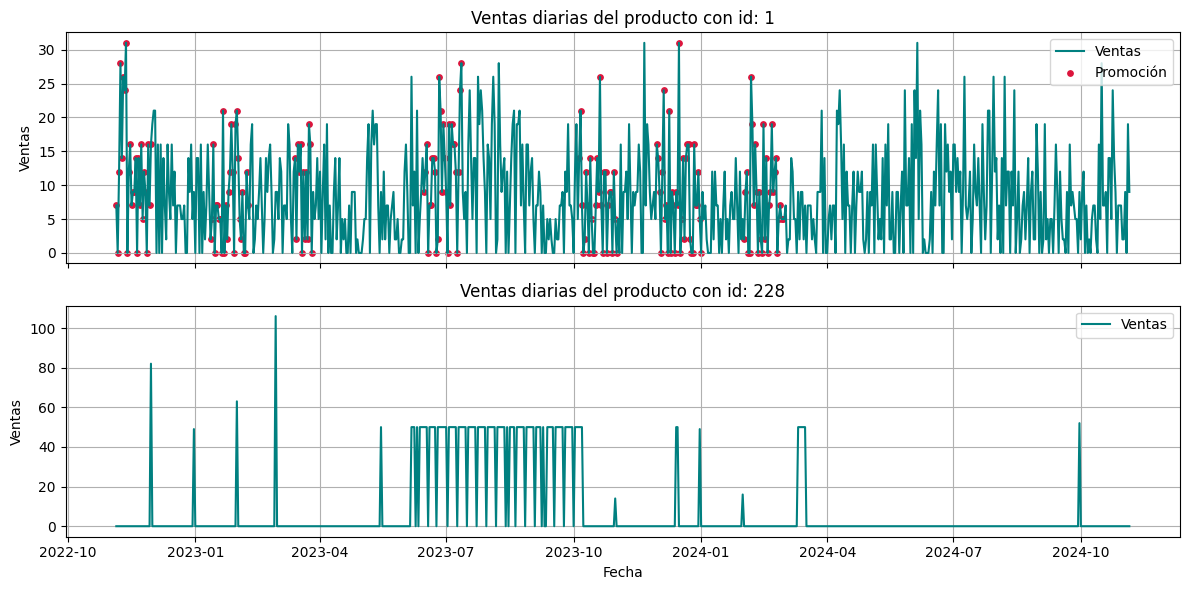

In [49]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(12, 6))
for i, prod in enumerate(productos):
    datos = df_comp[df_comp['producto'] == prod]
    ax = plt.subplot(2, 1, i+1)
    sns.lineplot(data=datos, x='idSecuencia', y='udsVenta', label='Ventas', color='teal')
    prom = datos[datos['bolPromotion'] == 1]
    plt.scatter(prom['idSecuencia'], prom['udsVenta'], color='crimson', label='Promoción', s=15)
    plt.title(f'Ventas diarias del producto con id: {prod}')
    if i == 0:
        ax.set_xticklabels([])
        ax.set_xlabel('')
        plt.legend()
    else:
        plt.xlabel('Fecha')
    plt.ylabel('Ventas')
    plt.grid(True)    
plt.tight_layout()
plt.savefig('serie_temporal_comparativa.png')
plt.show()



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observaciones:</strong>
<ul>
    <li><strong>Producto 1</strong>. Presenta ventas frecuentes a lo largo del tiempo. Se observan picos, pero están distribuidos. Las promociones (puntos rojos) aparecen con regularidad, pero no siempre implican un gran cambio en las ventas. Se puede decir que es un producto estable y predecible.
</li>
    <li><strong>Producto 228</strong>. Presenta gran cantidad de días con ventas cero, seguidos por períodos cortos con ventas altas. Claramente muestra una venta intermitente. Se puede decir que es un producto de demanda irregular y difícil de prever.</li>
</ul>
</div>

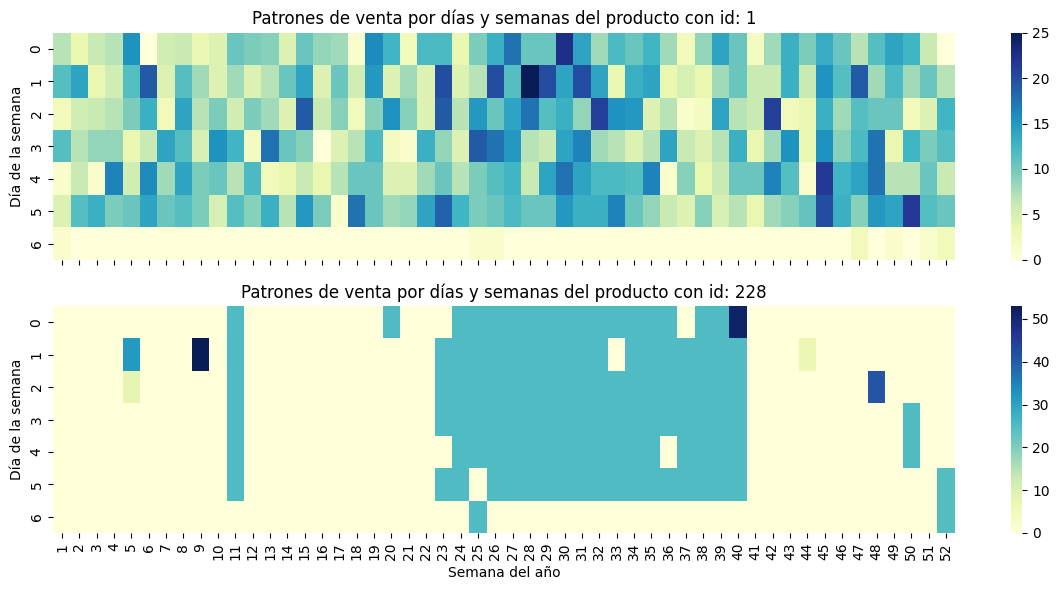

In [50]:
plt.figure(figsize=(12, 6))
for i, prod in enumerate(productos):
    datos = df_comp[df_comp['producto'] == prod]
    pivot = datos.pivot_table(index='day_of_week', columns='week_of_year', values='udsVenta', aggfunc='mean')
    ax = plt.subplot(2, 1, i+1)
    sns.heatmap(pivot, cmap='YlGnBu')
    plt.title(f'Patrones de venta por días y semanas del producto con id: {prod}')
    if i == 0:
        ax.set_xticklabels([])
        ax.set_xlabel('')
    else:
        plt.xlabel('Semana del año')
    plt.ylabel('Día de la semana')
plt.tight_layout()
plt.savefig('heatmap_semanal_2x1.png')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observaciones:</strong>
<ul>
    <li><strong>Producto 1</strong>. Tiene una distribución constante de actividad a lo largo de las semanas. Presenta colores suaves bastantes distribuidos que indican presencia estable de ventas por día de la semana. Se observa que los sábados (5) tienen mayor venta. 
</li>
    <li><strong>Producto 228</strong>. Múltiples zonas en blanco (sin ventas), seguidas por semanas con un patrón concentrado. Esto implica comportamiento eventual o dependiente de eventos, ya que las ventas no siguen un patrón predecible por semana o día.</li>
</ul>
</div>

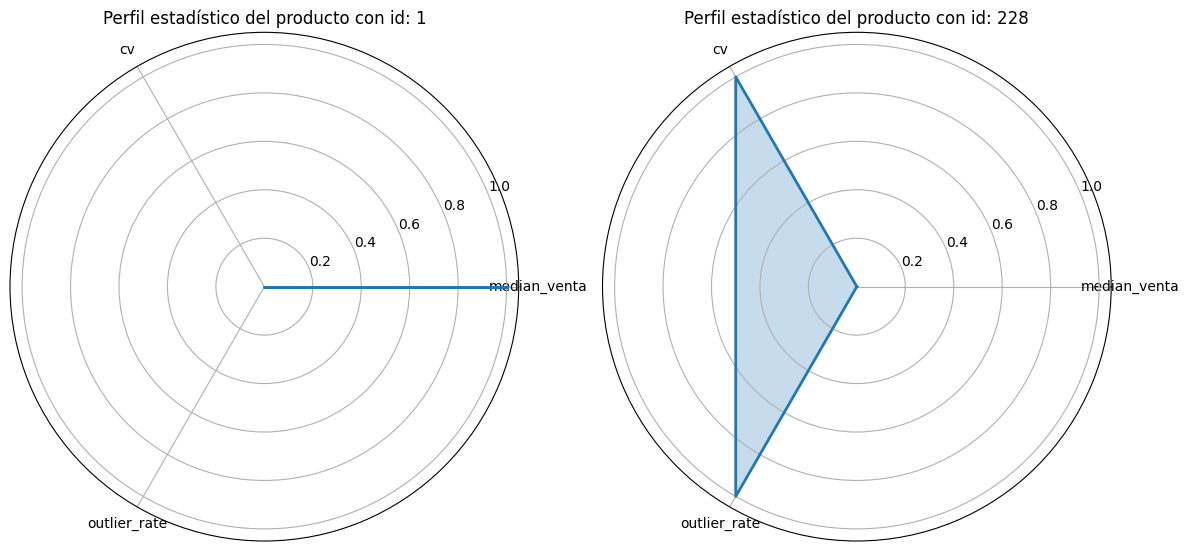

In [51]:
# Agrupar y normalizar métricas
resumen = df_comp.groupby('producto').agg({
    'median_venta': 'mean',
    'cv': 'mean',
    'outlier_rate': 'mean'
}).reset_index()

cols = ['median_venta', 'cv', 'outlier_rate']
resumen_norm = resumen.copy()
resumen_norm[cols] = resumen_norm[cols].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
labels = cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(12, 6))
for i, row in resumen_norm.iterrows():
    valores = row[cols].tolist()
    valores += valores[:1]
    ax = plt.subplot(1, 2, i+1, polar=True)
    ax.plot(angles, valores, label=f"Producto {int(row['producto'])}", linewidth=2)
    ax.fill(angles, valores, alpha=0.25)
    ax.set_title(f'Perfil estadístico del producto con id: {int(row["producto"])}')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
plt.tight_layout()
plt.savefig('radar_chart_comparativo.png')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Observaciones:</strong>
<ul>
    <li><strong>Producto 1</strong>. Tiene alta mediana de ventas, pero baja variabilidad (CV) y casi sin outliers. El perfil muestra un comportamiento centralizado, sin extremos.
</li>
    <li><strong>Producto 228</strong>. Tiene muy baja mediana de ventas, pero altísima variabilidad (CV) y alta tasa de outliers. El gráfico tiene una forma aguda, indicando comportamiento irregular.</li>
</ul>
</div>

In [52]:
# Crear tabla resumen
tabla_resumen2 = pd.DataFrame({
    'Grafico': ['Ventas diarías', 'Patron de ventas semanales', 'Perfil estadístico'],
    'Producto 1 (regular)': [
        'Flujo constante y predecible',
        'Patrón estable en días y semanas',
        'Alta mediana, baja variabilidad'
    ],
    'Producto 228 (irregular)': [
        'Huecos prolongados y picos irregulares',
        'Alta concentración y largos vacíos',
        'Alta variabilidad, alta atipicidad'
    ]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Mostrar la tabla
display(tabla_resumen2)

,Grafico,Producto 1 (regular),Producto 228 (irregular)
0,Ventas diarías,Flujo constante y predecible,Huecos prolongados y picos irregulares
1,Patron de ventas semanales,Patrón estable en días y semanas,Alta concentración y largos vacíos
2,Perfil estadístico,"Alta mediana, baja variabilidad","Alta variabilidad, alta atipicidad"


<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>El análisis comparativo entre los productos con comportamiento regular e irregular revela patrones representativos que permiten clasificar las series de ventas según su estabilidad. </li>
    <li>Los productos con demanda regular, como el identificado con ID 1, presentan ventas diarias sostenidas a lo largo del tiempo, sin grandes fluctuaciones ni interrupciones prolongadas. Este comportamiento se refleja en una serie temporal continua, un heatmap con actividad bien distribuida entre semanas y días, y un perfil estadístico caracterizado por alta mediana de ventas, baja variabilidad (CV) y escasa presencia de valores atípicos.</li>
    <li>En contraste, los productos con demanda irregular, como el producto 228, muestran ventas discontinuas, concentradas en períodos específicos y acompañadas de picos poco frecuentes pero significativos. Estas características se evidencian en series temporales intermitentes, heatmaps con grandes vacíos y métricas estadísticas que exhiben alta variabilidad relativa y una elevada tasa de atípicos.</li>
    <li>Este contraste refuerza la necesidad de aplicar enfoques diferenciados en la gestión y modelado de la demanda, ya que los productos regulares son más adecuados para métodos predictivos clásicos, mientras que los irregulares requieren estrategias específicas que consideren su naturaleza intermitente y menos predecible.</li>
</ul>
</div>

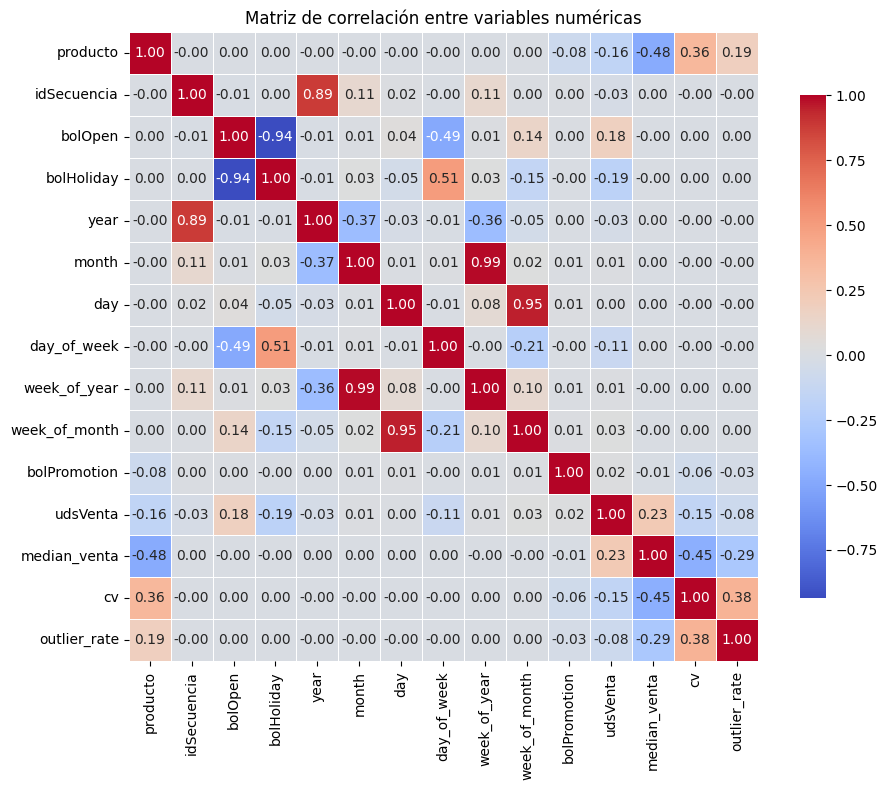

In [53]:
# Calcular matriz de correlación
corr = df.corr(method='pearson')

# Heatmap con anotaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.savefig("matrizCorrelacion.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Observaciones:</strong></p>
<strong>Enfoque con la variable objetivo udsVenta:</strong><br>
<ul>
    <li><strong>Correlaciones bajas:</strong> ninguna variable tiene correlaciones fuertes (> |0.5|)</li>
    <li><strong>Días festivos:</strong> el efecto negativo de bolHoliday es lógico y confirma que cerrar puntos de venta impacta negativamente en las ventas.</li>
    <li><strong>Mediana (+0.23):</strong> correlación relativamente baja, implica que los productos con mayor mediana tienden a tener más ventas diarias.</li>
    <li><strong>Coeficiente de variablidad (cv) y Tasa de atípicos (outlier_rate):</strong> tienen correlaciones negativas leves. A mayor venta diaria, parece haber menor variabilidad relativa y menos outliers.</li>
</ul>

<p><strong>Enfoque entre las variables dependientes:</strong></p>
 <ul>
    <li><strong>week_of_year <-> month:</strong> redundancia alta (+0.99). Los valores de semana del año ya están implícitos en el mes.</li>
    <li><strong>week_of_month <-> day:</strong> redundancia alta (+0.95). Días del mes explican prácticamente la semana del mes.</li>
    <li><strong>bolOpen <-> bolHoliday:</strong> redundancia alta (-0.94). Es un resultado lógico: si es festivo, normalmente está cerrado.</li>
    <li><strong>year <->  idSecuencia:</strong> redundancia alta (+0.85). El año está contenido en la fecha, así que hay dependencia directa.</li>   
    <li><strong>cv <->  outlier_rate:</strong> correlación moderada (+0.38). Los productos más variables también tienden a tener más valores atípicos, lo cual valida tus métricas.</li>
     <li><strong>median_venta <->  cv:</strong> correlación negativa moderada (-0.45) y <strong>median_venta <->  outlier_rate:</strong> correlación negativa moderada (-0.29). Productos con mayor venta típica tienen menor variabilidad y menos atipicidad, este es un patrón esperado y coherente con los perfiles que observados en los productos 1 y 228.</li>   
</ul>   
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
<strong>Conclusión:</strong>
<ul>
    <li>Se detectaron correlaciones elevadas entre algunas variables temporales y categóricas (por ejemplo, month y week_of_year, bolOpen y bolHoliday). Aunque estas colinealidades no afectan a los modelos de redes neuronales, sí se deben considerar al utilizar modelos lineales como ARIMA. Por ello, se evaluará la conveniencia de mantener o eliminar ciertas variables durante la fase de modelado, según el algoritmo. </li>
   <li>Las métricas derivadas <strong>cv, median_venta y outlier_rate</strong> están bien diseñadas porque reflejan comportamientos opuestos entre productos regulares e irregulares.</li>
</ul>
</div>